In [2]:
import pandas as pd
df = pd.read_csv('DS_BreastCancer.csv')
# Display all column names
columns = df.columns.tolist()
print(columns)

['chembl_id', 'molregno', 'iupac_name', 'smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ro3_pass', 'num_ro5_violations', 'cx_logp', 'cx_logd', 'molecular_species', 'qed_weighted', 'np_likeness_score', 'ic50_value', 'ic50_units', 'standard_relation', 'target_name', 'target_type', 'cell_description', 'disease_name', 'disease_category', 'mechanism_of_action', 'action_type', 'warning_type', 'warning_description', 'IUPACName']


/var/folders/ky/j161912n7lvbtpf0r6nlk1xh0000gn/T/ipykernel_10503/721474221.py:2: DtypeWarning: Columns (0: warning_description) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('DS_BreastCancer.csv')


In [3]:
import numpy as np

In [4]:
#removed unnecessary columns
df1 = df[['smiles', 'molecular_weight', 'aLogP', 'hba', 'hbd', 'psa', 'rtb', 'ic50_value', 'ic50_units']]

In [5]:
# Remove all null values from df1
df1 = df1.dropna()
print(f"Shape after removing nulls: {df1.shape}")
print(df1.info())

Shape after removing nulls: (43617, 9)
<class 'pandas.DataFrame'>
Index: 43617 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            43617 non-null  str    
 1   molecular_weight  43617 non-null  float64
 2   aLogP             43617 non-null  float64
 3   hba               43617 non-null  float64
 4   hbd               43617 non-null  float64
 5   psa               43617 non-null  float64
 6   rtb               43617 non-null  float64
 7   ic50_value        43617 non-null  float64
 8   ic50_units        43617 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.3 MB
None


In [6]:
#checked whether the units of IC50 values are the sane
print(df1['ic50_units'].unique())

<StringArray>
['nM', 'ug.mL-1', 'ug', 'ug/g', '%', 'pmol/L', '10'5uM', '10'6uM', '10^3nM']
Length: 9, dtype: str


In [7]:
# Keep only rows with nM units
units_to_keep = ['nM']
df1 = df1[df1['ic50_units'].isin(units_to_keep)]
print(f"Shape after filtering: {df1.shape}")
print(df1['ic50_units'].value_counts())

Shape after filtering: (41691, 9)
ic50_units
nM    41691
Name: count, dtype: int64


In [8]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41691 entries, 0 to 46290
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41691 non-null  str    
 1   molecular_weight  41691 non-null  float64
 2   aLogP             41691 non-null  float64
 3   hba               41691 non-null  float64
 4   hbd               41691 non-null  float64
 5   psa               41691 non-null  float64
 6   rtb               41691 non-null  float64
 7   ic50_value        41691 non-null  float64
 8   ic50_units        41691 non-null  str    
dtypes: float64(7), str(2)
memory usage: 3.2 MB


In [9]:
#added the pIC50 column
df1['pic50'] = -np.log10(df1['ic50_value']*1e-9)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Removed 2 rows with max pIC50 = 13.698970004336019
Shape after removing infinite values and max pIC50 outliers: (41687, 10)


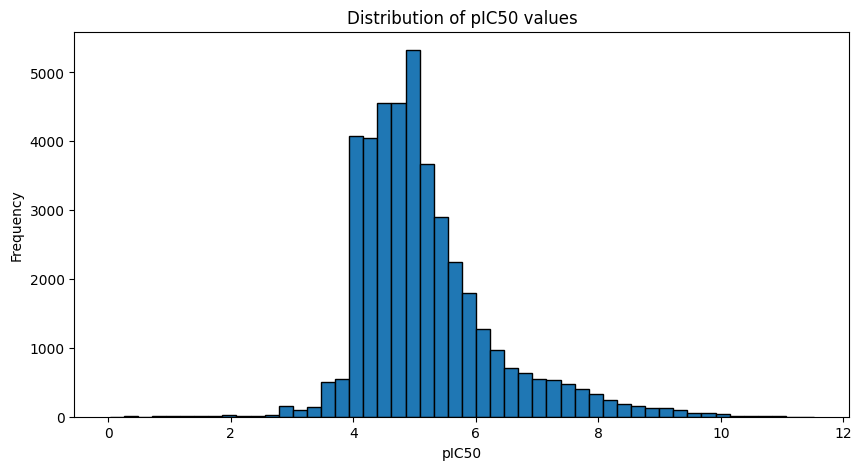

In [10]:
import matplotlib.pyplot as plt
# Remove infinite or NaN values
df1 = df1[np.isfinite(df1['pic50'])]

# Remove all rows with the maximum pIC50 value as outliers (I saw this at the box plot)
max_pic50 = df1['pic50'].max()
removed_count = df1[df1['pic50'] == max_pic50].shape[0]
df1 = df1[df1['pic50'] != max_pic50]
print(f"Removed {removed_count} rows with max pIC50 = {max_pic50}")
print(f"Shape after removing infinite values and max pIC50 outliers: {df1.shape}")

# Visualize the distribution of pIC50 values
plt.figure(figsize=(10, 5))
plt.hist(df1['pic50'], bins=50, edgecolor='black')
plt.xlabel('pIC50')
plt.ylabel('Frequency')
plt.title('Distribution of pIC50 values')
plt.show()


distribution is close to normal

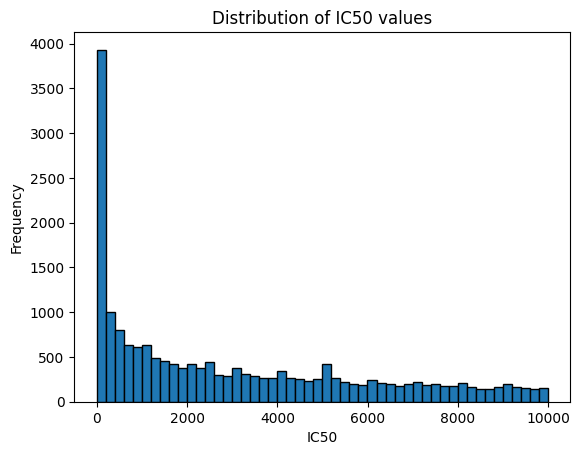

In [11]:
# Visualize the distribution of IC50 values (in nM)
plt.hist(df1['ic50_value'][df1['ic50_value']<10000], bins=50, edgecolor='black')
plt.xlabel('IC50')
plt.ylabel('Frequency')
plt.title('Distribution of IC50 values')
plt.show()

from these 2 graphs it is obvious that pIC50 distr is better for machine learning than IC50 values distr

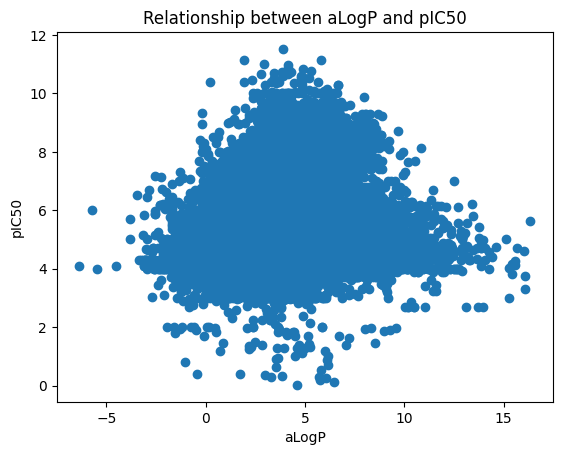

In [12]:
# Visualize the relationship between aLogP and pIC50
plt.scatter(df1['aLogP'], df1['pic50'])
plt.xlabel('aLogP')
plt.ylabel('pIC50')
plt.title('Relationship between aLogP and pIC50')
plt.show()

most active compounds (high pIC50) have approx 2<aLogP<7, which corresponds toLipinski's Rule of 5

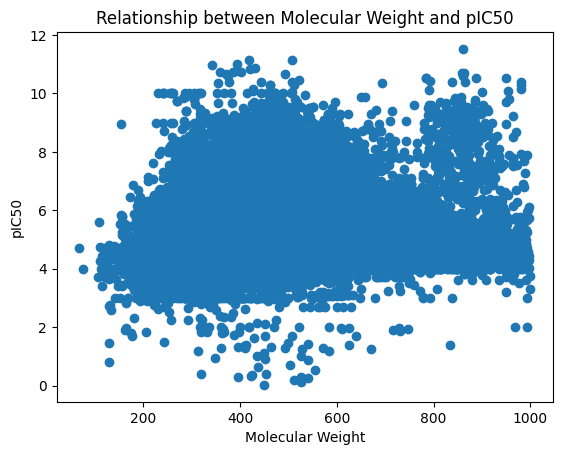

In [13]:
# Visualize the relationship between molecular weight and pIC50
plt.scatter(df1['molecular_weight'], df1['pic50'])
plt.xlabel('Molecular Weight')
plt.ylabel('pIC50')
plt.title('Relationship between Molecular Weight and pIC50')
plt.show()

most active compounds (high pIC50) have approx 200<molecular_weight<500 (small molecules don't have the required affinity to target proteins; large molecules get into cells with difficulty)

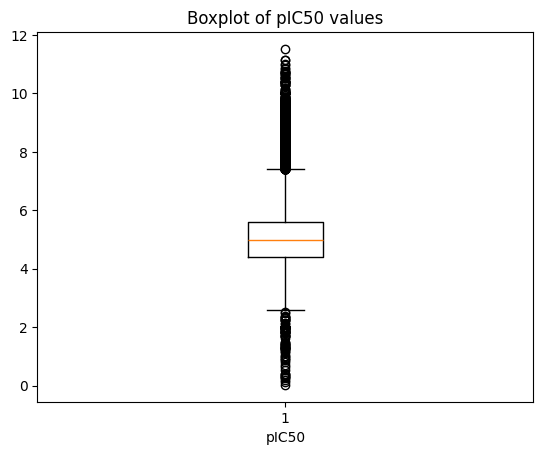

In [14]:
# Visualize the boxplot of pIC50 values
plt.boxplot(df1['pic50'])
plt.xlabel('pIC50')
plt.title('Boxplot of pIC50 values')
plt.show()

there was an obvious outlier at 13.8, I removed it earlier

In [15]:
df1['ic50_value'].describe()

count    4.168700e+04
mean     2.401592e+05
std      9.548970e+06
min      3.000000e-03
25%      2.500000e+03
50%      1.043000e+04
75%      4.000000e+04
max      9.506048e+08
Name: ic50_value, dtype: float64

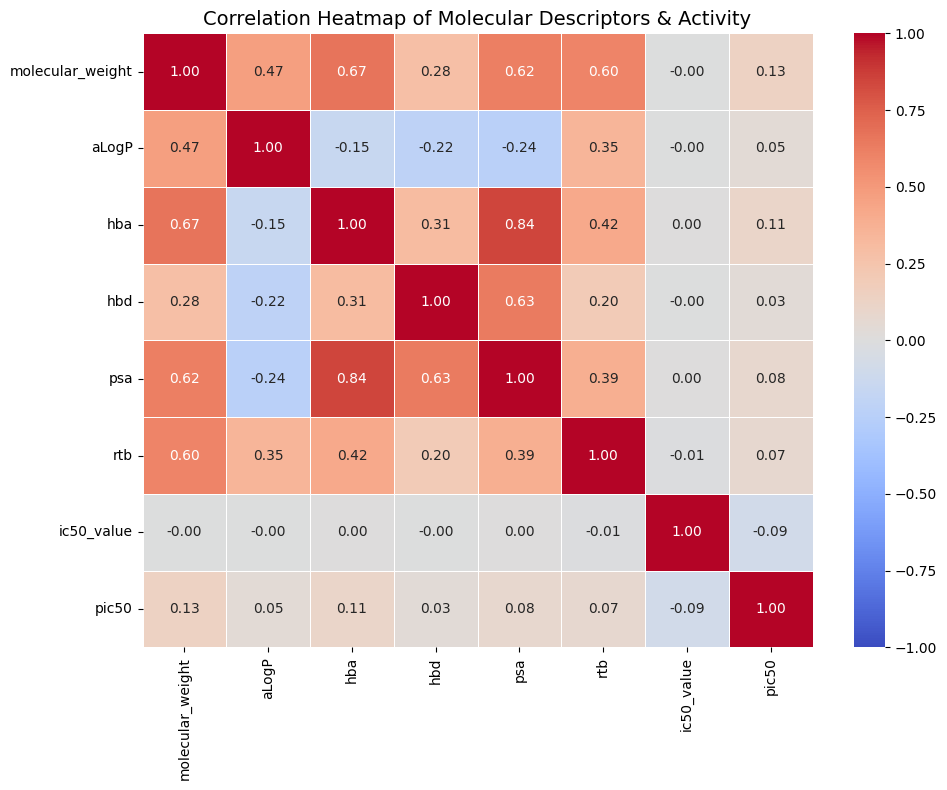

In [16]:
#creating a heatmap of correlations
import seaborn as sns

# 1. Отбираем только числовые колонки для анализа
# (ic50_value и pic50 сильно связаны, но pic50 линейнее, поэтому оставим все для проверки)
numeric_cols = [
    "molecular_weight",
    "aLogP",
    "hba",
    "hbd",
    "psa",
    "rtb",
    "ic50_value",
    "pic50",
]
corr_matrix = df1[numeric_cols].corr(method="pearson")

# 2. Настраиваем размер полотна
plt.figure(figsize=(10, 8))

# 3. Строим тепловую карту
sns.heatmap(
    corr_matrix,
    annot=True,  # Выводить коэффициенты внутри ячеек
    cmap="coolwarm",  # Красивая палитра: синий (минус) -> белый (ноль) -> красный (плюс)
    fmt=".2f",  # Округление до 2 знаков после запятой
    linewidths=0.5,  # Расстояние между ячейками
    vmin=-1,
    vmax=1,  # Границы шкалы
)

# 4. Добавляем заголовки
plt.title("Correlation Heatmap of Molecular Descriptors & Activity", fontsize=14)
plt.tight_layout()

# 5. Показываем график
plt.show()

strong correlation between molecular weight and polar surface area (PSA), since larger molecules tend to have larger surface areas. 

moderate correlation between aLogP andmolecular weight, since larger molecules often have more hydrophobic regions. 

strong correlation between hba and hbd, since both are related to the presence of hydrogen bond donors and acceptors in the molecule.

only -0.09 between pIC50 and ic50_value (cause pIC50 = -log10(IC50), non-linear relationship, see later)

In [17]:
#checking for pIC50 outliers that I mentioned earlier
a=df1[df1['pic50']==df1['pic50'].max()]
print(len(a))
print(a)

1
                                                  smiles  molecular_weight  \
14274  C/C=C(\C)[C@H]1OC(=O)[C@@H](C)NC(=O)[C@H]([C@@...            860.49   

       aLogP   hba  hbd     psa  rtb  ic50_value ic50_units      pic50  
14274   3.89  10.0  4.0  200.75  7.0       0.003         nM  11.522879  


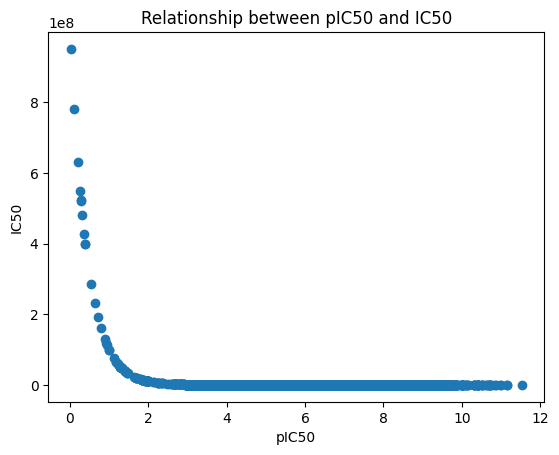

In [18]:
# Visualize the relationship between pIC50 and IC50 values
plt.scatter(df1['pic50'], df1['ic50_value'])
plt.xlabel('pIC50')
plt.ylabel('IC50')
plt.title('Relationship between pIC50 and IC50')
plt.show()

clear exponential relationship

99% of pIC50 values are in 0<IC50<1

but 1% spoils everything, so ic50_values cannot be used for machine learning at all

pIC50 should be used instead

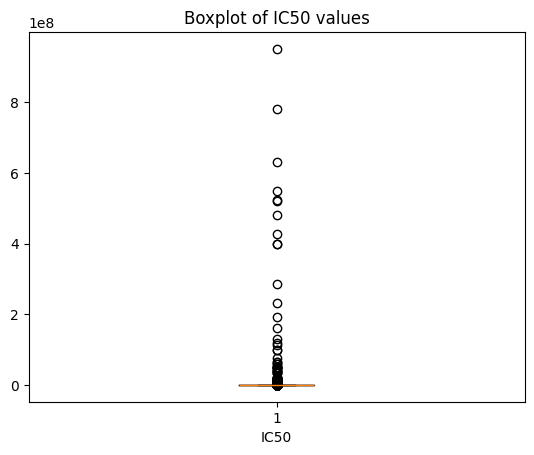

In [19]:
# Visualize the boxplot of IC50 values
plt.boxplot(df1['ic50_value'])
plt.xlabel('IC50')
plt.title('Boxplot of IC50 values')
plt.show()

insane number of outliers

ic50_values cannot be used for machine learning at all, pIC50 should be used instead

no need for ic50_values and ic50_units columns at this point

In [20]:
df1.info()

<class 'pandas.DataFrame'>
Index: 41687 entries, 0 to 46290
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41687 non-null  str    
 1   molecular_weight  41687 non-null  float64
 2   aLogP             41687 non-null  float64
 3   hba               41687 non-null  float64
 4   hbd               41687 non-null  float64
 5   psa               41687 non-null  float64
 6   rtb               41687 non-null  float64
 7   ic50_value        41687 non-null  float64
 8   ic50_units        41687 non-null  str    
 9   pic50             41687 non-null  float64
dtypes: float64(8), str(2)
memory usage: 3.5 MB


In [21]:
df_final = df1.drop(columns=['ic50_value', 'ic50_units'])
print(df_final.info())

<class 'pandas.DataFrame'>
Index: 41687 entries, 0 to 46290
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   smiles            41687 non-null  str    
 1   molecular_weight  41687 non-null  float64
 2   aLogP             41687 non-null  float64
 3   hba               41687 non-null  float64
 4   hbd               41687 non-null  float64
 5   psa               41687 non-null  float64
 6   rtb               41687 non-null  float64
 7   pic50             41687 non-null  float64
dtypes: float64(7), str(1)
memory usage: 2.9 MB
None


# RDKit 

In [22]:
from rdkit import Chem
from rdkit.Chem import AllChem
import pandas as pd
import numpy as np

# Convert SMILES to RDKit molecule objects
df_final['mol'] = df_final['smiles'].apply(Chem.MolFromSmiles)

# Remove invalid molecules
df_final = df_final[df_final['mol'].notnull()]

# Function to generate Morgan fingerprints
def mol_to_fp(mol, radius=2, n_bits=2048):
    fp = AllChem.GetMorganFingerprintAsBitVect(
        mol,
        radius,
        nBits=n_bits
    )
    return np.array(fp)

# Generate fingerprints
fingerprints = df_final['mol'].apply(mol_to_fp)

# Convert to dataframe
fp_df = pd.DataFrame(fingerprints.tolist())

# Final X and y
X = fp_df
y = df_final['pic50']

[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerator
[13:28:46] DEPRECATION WARNING: please use MorganGenerat

# Linear Regression Model

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [24]:
lr = LinearRegression()
lr.fit(X_train, y_train)

#predicted pic50 values for the test set
y_pred = lr.predict(X_test)

In [25]:
#coeffitions of linear regression model
coeff_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_
})
print(coeff_df.sort_values(by='Coefficient', ascending=False))

      Feature  Coefficient
1709     1709     0.896737
1052     1052     0.830570
1702     1702     0.763404
830       830     0.631670
512       512     0.626076
...       ...          ...
1684     1684    -0.509579
851       851    -0.521649
1334     1334    -0.550825
1111     1111    -0.568724
543       543    -0.626199

[2048 rows x 2 columns]


Accuracy evaluation

In [26]:
#Mean Squared Error between predicted and actual pic50 values
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

#Root Mean Squared Error
rmse = np.sqrt(mse)
print("RMSE:", rmse)

#R2
r2 = r2_score(y_test, y_pred)
print("R2:", r2)

MSE: 0.7303065186620623
RMSE: 0.8545797321853955
R2: 0.4192761553560348


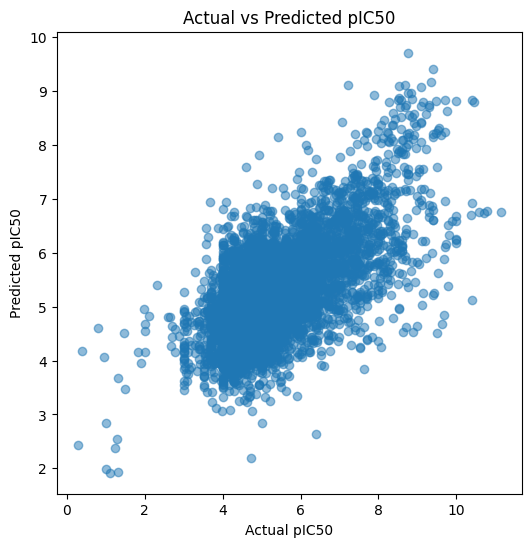

In [27]:
#pred VS exp plot
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Actual vs Predicted pIC50")
plt.show()

R2 with scaling: 0.4192761553560367
RMSE with scaling: 0.8545797321853941


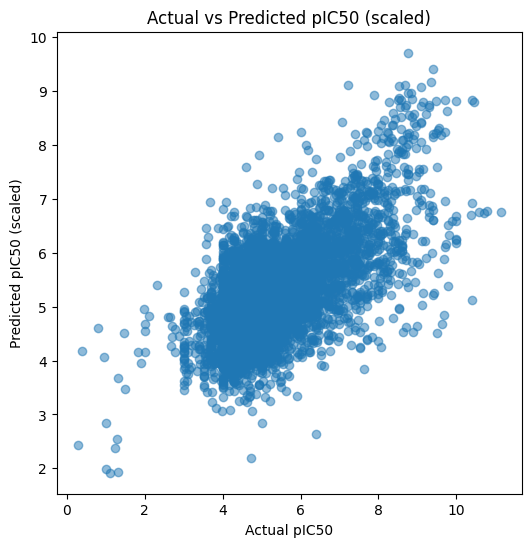

In [28]:
#trying linear regression scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr.fit(X_train_scaled, y_train)
y_pred_scaled = lr.predict(X_test_scaled)
r2_scaled = r2_score(y_test, y_pred_scaled)
print("R2 with scaling:", r2_scaled)
rmse_scaled = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print("RMSE with scaling:", rmse_scaled)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_scaled, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50 (scaled)")
plt.title("Actual vs Predicted pIC50 (scaled)")
plt.show()

# Random Forest

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [30]:
r2_rf = r2_score(y_test, y_pred_rf)
print("R2 with Random Forest:", r2_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print("RMSE with Random Forest:", rmse_rf)

R2 with Random Forest: 0.6957679109311596
RMSE with Random Forest: 0.6185435307845525


### Feature importnace

In [31]:
#coefficients of random forest model
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})
print(feature_importance_df.sort_values(by='Importance', ascending=False))

      Feature  Importance
1892     1892    0.026715
1994     1994    0.023381
381       381    0.011470
1709     1709    0.011466
797       797    0.011409
...       ...         ...
1359     1359    0.000013
545       545    0.000013
1215     1215    0.000012
148       148    0.000011
1606     1606    0.000011

[2048 rows x 2 columns]


Conclusion: polar surface area (PSA), molecular weight, and lipophilicity (aLogP) are the most influential descriptors for predicting anticancer activity (pIC50), which aligns with Lipinski’s rule of five.
RDKit can be used to add more information to decrease overfitting (see later) and identify major and minor features

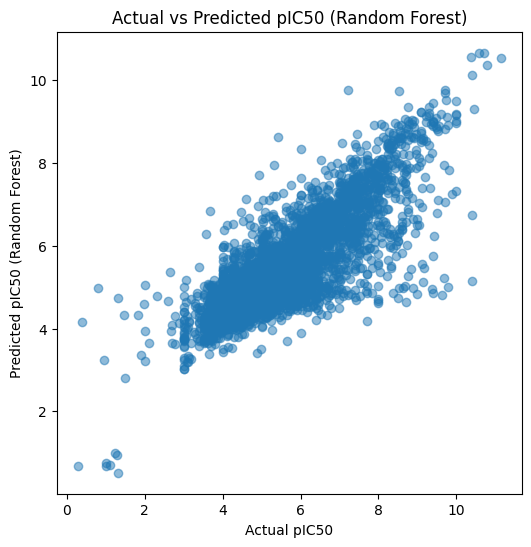

In [32]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50 (Random Forest)")
plt.title("Actual vs Predicted pIC50 (Random Forest)")
plt.show()

### Overfitting evaluation

In [33]:
# Overfitting evaluation

# Predictions for training set
y_train_pred_rf = rf.predict(X_train)

# Predictions for test set
y_test_pred_rf = rf.predict(X_test)

# R2 for training set
r2_train_rf = r2_score(y_train, y_train_pred_rf)

# R2 for test set
r2_test_rf = r2_score(y_test, y_test_pred_rf)

# RMSE for training set
rmse_train_rf = np.sqrt(
    mean_squared_error(y_train, y_train_pred_rf)
)

# RMSE for test set
rmse_test_rf = np.sqrt(
    mean_squared_error(y_test, y_test_pred_rf)
)

print("Train R2:", r2_train_rf)
print("Test R2:", r2_test_rf)

print("Train RMSE:", rmse_train_rf)
print("Test RMSE:", rmse_test_rf)

Train R2: 0.9546749508165683
Test R2: 0.6957679109311596
Train RMSE: 0.23567270563249806
Test RMSE: 0.6185435307845525


Conclusion: the substantial gap between training and test performance (Train R² ≈ 0.95 vs Test R² ≈ 0.70) suggests noticeable overfitting. The model fits the training data extremely well but partially memorizes dataset-specific patterns and noise, which reduces generalization to unseen compounds


# XGBoost

In [34]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=300, #number of trees
    max_depth=6, #maximum depth of each tree
    learning_rate=0.05, #how much each tree corrects the error
    subsample=0.8, #random sample fraction of the data for each tree to prevent overfitting
    colsample_bytree=0.8, 
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [35]:
r2_xgb = r2_score(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

print("R2:", r2_xgb)
print("RMSE:", rmse_xgb)

R2: 0.5223790560077566
RMSE: 0.7750138087366066


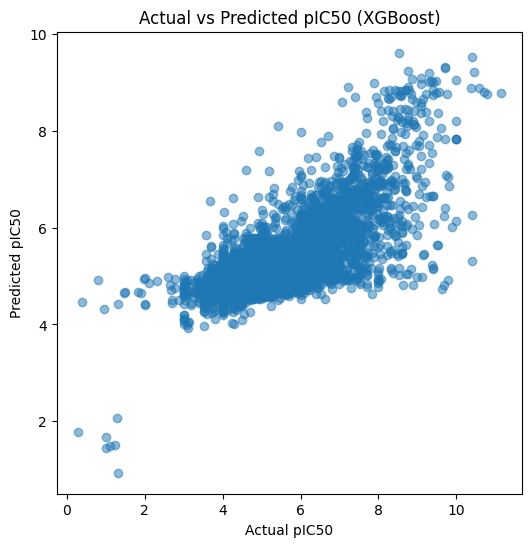

In [36]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_xgb, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (XGBoost)")

plt.show()

### Feature Importnace

In [37]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

      Feature  Importance
1994     1994    0.017694
1832     1832    0.011968
797       797    0.011633
1892     1892    0.010785
1035     1035    0.009697
...       ...         ...
509       509    0.000000
1632     1632    0.000000
1322     1322    0.000000
941       941    0.000000
1715     1715    0.000000

[2048 rows x 2 columns]


### Overfitting

In [38]:
y_train_pred = xgb.predict(X_train)
y_test_pred = xgb.predict(X_test)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)
print("Train R2:", r2_train)
print("Test R2:", r2_test)

Train R2: 0.6151102561530934
Test R2: 0.5223790560077566


Conclusion: XGBoost demonstrated strong predictive capability with moderate generalization performance (Test R² ≈ 0.52). The relatively small difference between training and test R² values indicates controlled overfitting and improved robustness compared to Random Forest. Although the predictive accuracy was lower, the model generalized more consistently to unseen data, suggesting that boosting-based regularization helped reduce memorization of training-specific patterns.


# LightGBM

In [39]:
from lightgbm import LGBMRegressor

# LightGBM model
lgbm = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

# Train
lgbm.fit(X_train, y_train)

# Predictions
y_pred_lgbm = lgbm.predict(X_test)

# Metrics
r2_lgbm = r2_score(y_test, y_pred_lgbm)

rmse_lgbm = np.sqrt(
    mean_squared_error(y_test, y_pred_lgbm)
)

print("R2:", r2_lgbm)
print("RMSE:", rmse_lgbm)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.086286 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4096
[LightGBM] [Info] Number of data points in the train set: 33349, number of used features: 2048
[LightGBM] [Info] Start training from score 5.165366
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gai

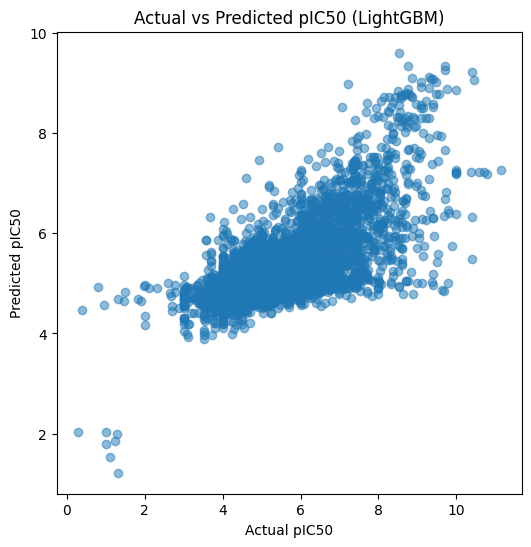

In [40]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_lgbm, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (LightGBM)")

plt.show()

Conclusion: LightGBM performed a bit worse than XGBoost, these models are close to each other

### Feature importance

In [41]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': lgbm.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

      Feature  Importance
656       656         104
314       314          88
378       378          86
80         80          82
1088     1088          77
...       ...         ...
913       913           0
912       912           0
910       910           0
909       909           0
2047     2047           0

[2048 rows x 2 columns]


### Overfitting

In [42]:
y_train_pred_lgbm = lgbm.predict(X_train)

r2_train_lgbm = r2_score(
    y_train,
    y_train_pred_lgbm
)

r2_test_lgbm = r2_score(
    y_test,
    y_pred_lgbm
)

print("Train R2:", r2_train_lgbm)
print("Test R2:", r2_test_lgbm)

Train R2: 0.5695087360111366
Test R2: 0.4954687914721758


Conclusion: the gap between training and testing performance remained relatively limited, indicating acceptable generalization ability. The results suggest that LightGBM efficiently utilized high-dimensional fingerprint features, although its predictive capability was slightly lower than that of Random Forest and XGBoost.


# CatBoost

In [43]:
from catboost import CatBoostRegressor

# CatBoost model
catboost = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=0,
    random_state=42
)

# Train
catboost.fit(X_train, y_train)

# Predictions
y_pred_cat = catboost.predict(X_test)

# Metrics
r2_cat = r2_score(y_test, y_pred_cat)

rmse_cat = np.sqrt(
    mean_squared_error(y_test, y_pred_cat)
)

print("R2:", r2_cat)
print("RMSE:", rmse_cat)

R2: 0.39754125249560845
RMSE: 0.8704251210145689


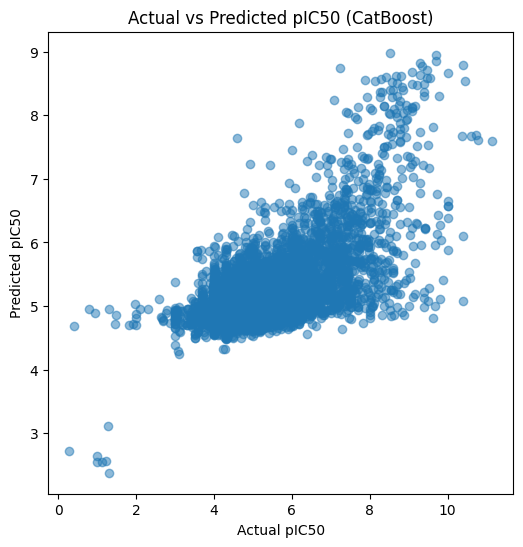

In [44]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred_cat, alpha=0.5)

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")

plt.title("Actual vs Predicted pIC50 (CatBoost)")

plt.show()

### Feature Importnace

In [45]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': catboost.feature_importances_
})

print(
    importance_df.sort_values(
        by='Importance',
        ascending=False
    )
)

      Feature  Importance
1832     1832    5.681396
1994     1994    3.086262
1892     1892    2.865812
1313     1313    1.997341
949       949    1.841732
...       ...         ...
771       771    0.000000
770       770    0.000000
768       768    0.000000
766       766    0.000000
2047     2047    0.000000

[2048 rows x 2 columns]


### Overfitting

In [46]:
y_train_pred_cat = catboost.predict(X_train)

r2_train_cat = r2_score(
    y_train,
    y_train_pred_cat
)

r2_test_cat = r2_score(
    y_test,
    y_pred_cat
)

print("Train R2:", r2_train_cat)
print("Test R2:", r2_test_cat)

Train R2: 0.44795915354501203
Test R2: 0.39754125249560845


Conclusion: CatBoost showed the weakest performance among the ensemble methods (Test R² ≈ 0.40), with relatively low training performance as well. The small gap between training and test R² values indicates limited overfitting; however, this also suggests that the model underfit the data and was unable to fully capture the complexity of the molecular structure–activity relationships present in the dataset.


# Overall Table

In [47]:
# Create comparison table

results_df = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'LightGBM',
        'CatBoost',
    ],

    'R2': [
        r2,
        r2_rf,
        r2_xgb,
        r2_lgbm,
        r2_cat,
    ],

    'RMSE': [
        rmse,
        rmse_rf,
        rmse_xgb,
        rmse_lgbm,
        rmse_cat,
    ]

})

# Sort by R2
results_df = results_df.sort_values(
    by='R2',
    ascending=False
)

# Reset index
results_df = results_df.reset_index(drop=True)

print(results_df)

               Model        R2      RMSE
0      Random Forest  0.695768  0.618544
1            XGBoost  0.522379  0.775014
2           LightGBM  0.495469  0.796548
3  Linear Regression  0.419276  0.854580
4           CatBoost  0.397541  0.870425


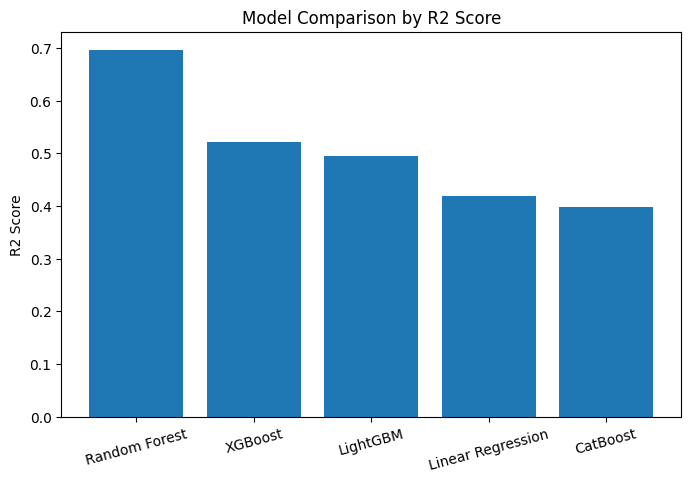

In [48]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['R2']
)

plt.ylabel("R2 Score")

plt.title("Model Comparison by R2 Score")

plt.xticks(rotation=15)

plt.show()

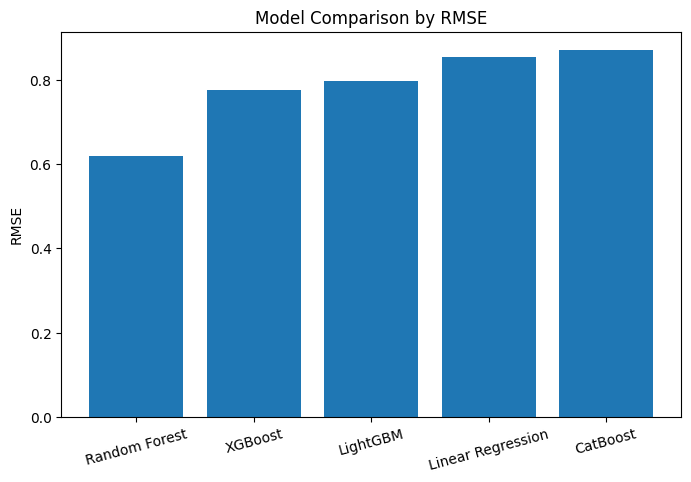

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df['Model'],
    results_df['RMSE']
)

plt.ylabel("RMSE")

plt.title("Model Comparison by RMSE")

plt.xticks(rotation=15)

plt.show()

Conclusion: The incorporation of RDKit-generated Morgan fingerprints significantly improved the predictive performance of all machine learning models compared to the initial descriptor-based approach. While the original models relied only on six physicochemical descriptors, the fingerprint-based representation captured substantially more structural information about the molecules, including local atomic environments and substructural patterns associated with anticancer activity.

Among all tested models, Random Forest achieved the best predictive performance (R² ≈ 0.70, RMSE ≈ 0.62), demonstrating that ensemble tree-based methods are highly effective for QSAR modeling with high-dimensional molecular fingerprints. XGBoost and LightGBM also showed strong predictive capability, while Linear Regression improved considerably compared to the descriptor-only setup, indicating that molecular fingerprints partially linearized the structure–activity relationship.

Overall, the results demonstrate that molecular fingerprints generated with RDKit provide a significantly more informative representation of anticancer compounds than traditional molecular descriptors alone. The study confirms the importance of cheminformatics-based feature engineering in modern computational drug discovery and QSAR modeling.
